In [1]:
import pandas as pd              # Para análisis de datos
import numpy as np               # Para cálculos numéricos
import matplotlib.pyplot as plt  # Para gráficos
import seaborn as sns            # Para gráficos bonitos

Metodo de Brent: Interpolacion parabolica para optimizacion de funciones (pagina 188 Chapra). Recordar que $\rm{max}(f) = \rm{min}(-f)$. Es necesario conocer tres puntos y sus imágenes:

$(x_1,x_2,x_3)$ y $(f(x_1),f(x_2),f(x_3))$. 

In [2]:
def MetBrent(px,func,maxit):
    # px = vector con los 3 puntos con px[0] = x1,; px[1] = x2; px[2] = x3
    # func = funcion f(x) 
    # maxit = numero maximo de iteraciones que queremos 

    iter = 0

    if len(px)!=3:
        print("Cantidad de puntos diferente de 3. Vuelve a intentarlo.")
        return
    else:
        if maxit == None:
            maxit = 20 # Si no se introduce un maxit pongo un valor predeterminado de 20 iteraciones

        while iter < maxit:
            d = px[1] -  0.5 * ((((px[1] - px[0])**2) * (func(px[1]) - func(px[2]))) - (((px[1]-px[2])**2) * (func(px[1]) - func(px[0])))) / (((px[1] - px[0]) * (func(px[1]) - func(px[2]))) - ((px[1]-px[2]) * (func(px[1]) - func(px[0]))))

            r0d = abs(px[0] - d)
            r1d = abs(px[1] - d)
            r2d = abs(px[2] - d)
            
            iter = iter + 1 

            # Aqui lo que hago es ver que punto esta mas lejos de "d" para eliminarlo
            if r0d > r1d and r0d > r2d:
                px[0] = d
            else:
                if r1d > r0d and r1d > r2d:
                    px[1] = d
                else:
                    px[2] = d
        
        return d 

El problema es hallar el minimo de una función. Esta función por ejemplo es $f(x) = \frac{x^2}{10} - 2\sin(x)$, y los puntos que tenemos en este caso (cerca del mínimo) son $\vec{x} = (0,1,4)$.  

In [3]:
def f(x):
    valor = (x**2)/10 -2*np.sin(x)
    return valor

px = [0,1,4]

d = MetBrent(px,f,4)
solucion = [float(d),float(f(d))]

print('El minimo encontrado es ( d , f(d) ) = ', solucion, ' .')

El minimo encontrado es ( d , f(d) ) =  [1.427617579518234, -1.7757256484290336]  .


Comprobación gráfica del resultado:

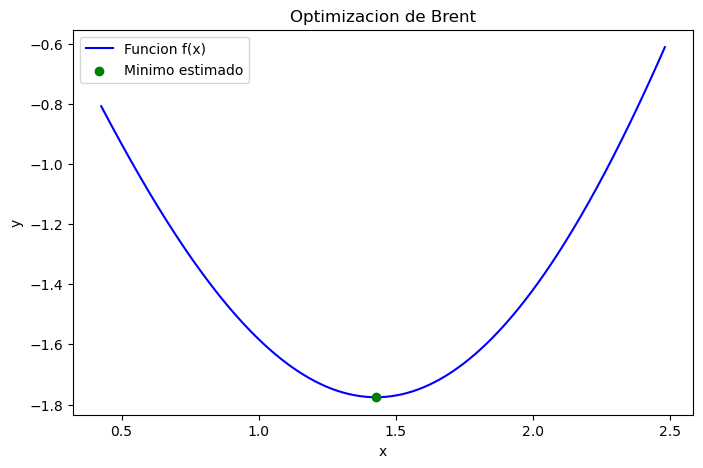

In [4]:
x_vals = np.linspace(min(px) - 1, max(px) + 1, 500)
y_vals = f(x_vals)

plt.figure(figsize=(8, 5))
plt.plot(x_vals, y_vals, label='Funcion f(x)', color='blue')
plt.scatter(d, f(d), color='green', label='Minimo estimado', zorder=5)
plt.title('Optimizacion de Brent')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(False)
plt.show()